# Project 3 — Multimodal BEV Perception

**Experiment ID:** P3-2B  
**Architecture:** LiDAR Baseline      
**Task:** BEV Occupancy Prediction  
**Dataset:** nuScenes-mini

This notebook establishes the LiDAR-only baseline for Project 3.

Instead of RGB imagery, the model receives a LiDAR-derived Bird's-Eye-View
(BEV) occupancy representation as input and learns to reconstruct the
target BEV occupancy map.

This baseline isolates the contribution of LiDAR geometry before
introducing multimodal sensor fusion.

## Metadata

**Project**

Cross-Domain Multimodal Sensor Fusion for BEV Occupancy Prediction

**Dataset**

NuScenes Mini v1.0

**Input**

- LiDAR-derived BEV occupancy grid

**Target**

- LiDAR-derived BEV occupancy map

**Objective**

Learn the mapping

```text
  Input BEV
      ↓
   Encoder
      ↓
 Latent Representation
      ↓
   Decoder
      ↓
  Target BEV
```

This baseline quantifies how much information can be recovered from
LiDAR geometry alone.

In [ ]:
from google.colab import drive

drive.mount('/content/drive')
%cd /content/drive/MyDrive/Colab Notebooks/project3_multimodal_bev_perception
!ls

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Colab Notebooks/project3_multimodal_bev_perception
checkpoints	data	    dummy.onnx	nuscenes   reports  src
colab_packages	deployment  notebooks	README.md  scripts


In [ ]:
import os, sys
# --- System ---
sys.path.append('/content/drive/MyDrive/Colab Notebooks/project3_multimodal_bev_perception/colab_packages')


In [ ]:
import sys, os, importlib
# Make sure your src/ directory is visible to Python
project_root = "/content/drive/MyDrive/Colab Notebooks/project3_multimodal_bev_perception"
src_path = os.path.join(project_root, "src")

if src_path not in sys.path:
    sys.path.append(src_path)
    print(f" Added to sys.path: {src_path}")

# Clear any stale caches
importlib.invalidate_caches()

## 1. Environment Setup

Configure the project environment, import required libraries,
and initialize the runtime for model training and evaluation.

In [ ]:
import os, sys, torch, random
import numpy as np
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split

# Ensure src is discoverable
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from src.dataset_utils import RGBBEVDataset
from src.losses import HybridLoss
from src.model_rgb_bev import RGBtoBEV  # we'll modify architecture for BEV→BEV

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Running on:", device)


Running on: cuda


## 2. Dataset Loading

Load the synchronized multimodal dataset generated during Phase 1.

Each HDF5 sample contains

- RGB image
- LiDAR-derived BEV occupancy map
- IMU feature window

Only the BEV representation is used in this LiDAR baseline.

In [ ]:
data_dir = "/content/drive/MyDrive/Colab Notebooks/project3_multimodal_bev_perception/data/preprocessed_moving"
assert os.path.exists(data_dir), f"Folder not found: {data_dir}"

# Collect all .h5 files
h5_files = sorted([os.path.join(data_dir, f) for f in os.listdir(data_dir) if f.endswith(".h5")])
print(f"Found {len(h5_files)} BEV samples")

# Dataset: we only need the BEV (geometry)
full_dataset = RGBBEVDataset(h5_files)
n_total = len(full_dataset)
n_train = int(0.8 * n_total)
n_val = n_total - n_train
train_set, val_set = random_split(full_dataset, [n_train, n_val])

train_loader = DataLoader(train_set, batch_size=8, shuffle=True)
val_loader = DataLoader(val_set, batch_size=8, shuffle=False)
print(f"Train: {len(train_loader)} batches | Val: {len(val_loader)} batches")


Found 323 BEV samples
Train: 33 batches | Val: 9 batches


## 3. LiDAR Baseline Network

Define a lightweight encoder-decoder network operating directly on
LiDAR-derived BEV occupancy maps.

Pipeline

```text
  Input BEV
      ↓
   Encoder
      ↓
Latent Feature Map
      ↓
   Decoder
      ↓
Reconstructed BEV
```

The network serves as the LiDAR-only baseline for comparison with
RGB-only and multimodal fusion models.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

from src.model.lidar_baseline import LiDARBaselineModel


# ---------------------------------------------------
# Initialize LiDAR baseline model
# ---------------------------------------------------
model = LiDARBaselineModel().to(device)

# print(model)


# ---------------------------------------------------
# Optimizer & Loss
# ---------------------------------------------------
loss_fn = HybridLoss(bce_weight=0.7)

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3,
)


# ---------------------------------------------------
# Model Summary
# ---------------------------------------------------
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)
print("LiDAR Baseline")
print("-" * 15)

print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")

LiDAR Baseline
---------------
Total parameters     : 189,905
Trainable parameters : 189,905


## 4. Model Training

Train the LiDAR baseline using supervised learning.

For each epoch:

1. Forward pass
2. Compute Hybrid Loss (BCE + Dice)
3. Backpropagation
4. Parameter update
5. Validation
6. Save the best-performing checkpoint

In [ ]:
import os
import time
import torch


# ---------------------------------------------------
# Compute mean IoU using thresholded occupancy maps
# ---------------------------------------------------
def soft_iou(logits, target, smooth=1e-6):

    probs = torch.sigmoid(logits)

    pred_bin = (probs > 0.5).float()

    inter = (pred_bin * target).sum(dim=(2, 3))

    union = (
        pred_bin.sum(dim=(2, 3))
        + target.sum(dim=(2, 3))
        - inter
    )

    iou = (inter + smooth) / (union + smooth)

    return iou.mean().item()


# ---------------------------------------------------
# Train the LiDAR baseline model
# ---------------------------------------------------
t0 = time.time()

EPOCHS = 40
best_val_iou = 0.0

for epoch in range(EPOCHS):

    # ---------------------------------------------------
    # Training
    # ---------------------------------------------------
    model.train()

    train_loss = 0.0

    for rgb, bev, imu in train_loader:

        bev = bev.to(device)

        optimizer.zero_grad(set_to_none=True)

        logits = model(bev)

        loss = loss_fn(logits, bev)

        loss.backward()

        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ---------------------------------------------------
    # Validation
    # ---------------------------------------------------
    model.eval()

    val_loss = 0.0
    val_iou = 0.0

    with torch.no_grad():

        for rgb, bev, imu in val_loader:

            bev = bev.to(device)

            logits = model(bev)

            val_loss += loss_fn(logits, bev).item()

            val_iou += soft_iou(logits, bev)

    val_loss /= len(val_loader)
    val_iou /= len(val_loader)

    print(
        f"Epoch {epoch + 1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val IoU: {val_iou:.4f}"
    )

    # ---------------------------------------------------
    # Save best-performing checkpoint
    # ---------------------------------------------------
    if val_iou > best_val_iou:

        best_val_iou = val_iou

        os.makedirs("checkpoints", exist_ok=True)

        torch.save(
            model.state_dict(),
            "checkpoints/lidar_baseline_best.pth",
        )


t1 = time.time()

print(f"\nTraining complete. Best Val IoU: {best_val_iou:.4f}")

print(f"Total training time: {(t1 - t0) / 60:.2f} minutes")

Epoch 1/40 | Train Loss: 0.5926 | Val Loss: 0.5397 | Val IoU: 0.3476
Epoch 2/40 | Train Loss: 0.5137 | Val Loss: 0.4845 | Val IoU: 0.3615
Epoch 3/40 | Train Loss: 0.4660 | Val Loss: 0.4539 | Val IoU: 0.3487
Epoch 4/40 | Train Loss: 0.4360 | Val Loss: 0.4133 | Val IoU: 0.4085
Epoch 5/40 | Train Loss: 0.4062 | Val Loss: 0.4048 | Val IoU: 0.3765
Epoch 6/40 | Train Loss: 0.3899 | Val Loss: 0.3741 | Val IoU: 0.4251
Epoch 7/40 | Train Loss: 0.3718 | Val Loss: 0.3623 | Val IoU: 0.4156
Epoch 8/40 | Train Loss: 0.3603 | Val Loss: 0.3474 | Val IoU: 0.4415
Epoch 9/40 | Train Loss: 0.3522 | Val Loss: 0.3451 | Val IoU: 0.4331
Epoch 10/40 | Train Loss: 0.3417 | Val Loss: 0.3317 | Val IoU: 0.4546
Epoch 11/40 | Train Loss: 0.3405 | Val Loss: 0.3302 | Val IoU: 0.4585
Epoch 12/40 | Train Loss: 0.3302 | Val Loss: 0.3210 | Val IoU: 0.4656
Epoch 13/40 | Train Loss: 0.3246 | Val Loss: 0.3244 | Val IoU: 0.4683
Epoch 14/40 | Train Loss: 0.3209 | Val Loss: 0.3137 | Val IoU: 0.4784
Epoch 15/40 | Train Loss: 0.3

In [ ]:
import numpy as np
import torch
import torch.nn.functional as F

from src.report_utils import save_report


# ---------------------------------------------------
# Compute evaluation metrics
# ---------------------------------------------------
def compute_metrics(pred, target, thresh=0.5):

    pred_bin = (pred > thresh).astype(np.uint8)
    target_bin = (target > 0.5).astype(np.uint8)

    tp = np.logical_and(pred_bin == 1, target_bin == 1).sum()
    fp = np.logical_and(pred_bin == 1, target_bin == 0).sum()
    fn = np.logical_and(pred_bin == 0, target_bin == 1).sum()

    precision = tp / (tp + fp + 1e-6)
    recall = tp / (tp + fn + 1e-6)

    f1 = (
        2.0 * precision * recall
        / (precision + recall + 1e-6)
    )

    inter = np.logical_and(pred_bin, target_bin).sum()
    union = np.logical_or(pred_bin, target_bin).sum()

    iou = inter / (union + 1e-6)

    return iou, precision, recall, f1


# ---------------------------------------------------
# Load the best-performing checkpoint
# ---------------------------------------------------
ckpt_path = "checkpoints/lidar_baseline_best.pth"

model.load_state_dict(
    torch.load(
        ckpt_path,
        map_location=device,
    )
)

model.eval()


# ---------------------------------------------------
# Evaluate on the validation set
# ---------------------------------------------------
iou_scores = []
prec_scores = []
rec_scores = []
f1_scores = []

with torch.no_grad():

    for rgb, bev, imu in val_loader:

        bev = bev.to(device)

        # ---------------------------------------------------
        # Forward propagation
        # ---------------------------------------------------
        logits = model(bev)

        # Convert logits to probabilities
        probs = torch.sigmoid(logits)

        # ---------------------------------------------------
        # Resize prediction if necessary
        # ---------------------------------------------------
        if probs.shape[-2:] != bev.shape[-2:]:

            probs = F.interpolate(
                probs,
                size=bev.shape[-2:],
                mode="bilinear",
                align_corners=False,
            )

        probs_np = probs.cpu().numpy()
        bev_np = bev.cpu().numpy()

        for pred, target in zip(probs_np, bev_np):

            iou, precision, recall, f1 = compute_metrics(
                pred[0],
                target[0],
            )

            iou_scores.append(iou)
            prec_scores.append(precision)
            rec_scores.append(recall)
            f1_scores.append(f1)


# ---------------------------------------------------
# Summarize validation metrics
# ---------------------------------------------------
summary_dict = {

    "Mean IoU": np.mean(iou_scores),

    "Mean Precision": np.mean(prec_scores),

    "Mean Recall": np.mean(rec_scores),

    "Mean F1 Score": np.mean(f1_scores),
}

print("\nValidation Metrics Summary — LiDAR Baseline\n")

for metric, value in summary_dict.items():
    print(f"{metric:17}: {value:.4f}")


# ---------------------------------------------------
# Save evaluation report and update leaderboard
# ---------------------------------------------------
_ = save_report(
    summary_dict,
    model_name="LiDAR Baseline",
    best_iou=np.mean(iou_scores),
    start_time=t0,
    end_time=t1,
    auto_update=True,
)


Validation Metrics Summary — LiDAR Baseline

Mean IoU         : 0.5577
Mean Precision   : 0.6793
Mean Recall      : 0.7562
Mean F1 Score    : 0.7155
 Markdown report saved → reports/lidar_baseline_summary.md
 CSV report saved → reports/lidar_baseline_summary.csv
 Leaderboard saved → reports/leaderboard.csv
️ Markdown summary → reports/leaderboard.md
 Leaderboard plot saved → reports/leaderboard.png


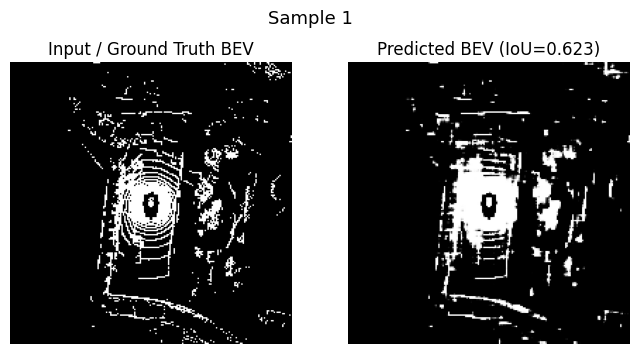

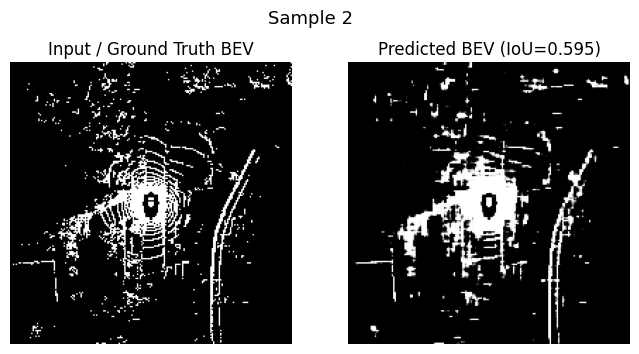

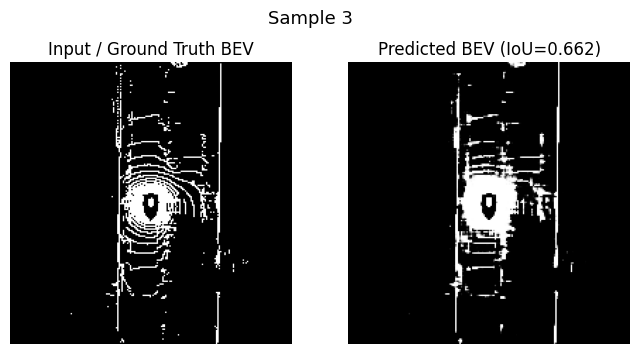

In [ ]:
# ---------------------------------------------------
# Load best-performing checkpoint
# ---------------------------------------------------
ckpt = "checkpoints/lidar_baseline_best.pth"
model.load_state_dict(torch.load(ckpt, map_location=device))
model.eval()

# ---------------------------------------------------
# Randomly select validation samples
# ---------------------------------------------------
indices = random.sample(range(len(val_set)), 3)
for i, idx in enumerate(indices):

    # ---------------------------------------------------
    # Load validation sample
    # ---------------------------------------------------
    rgb, bev, imu = val_set[idx]
    bev_in = bev.unsqueeze(0).to(device)

    # ---------------------------------------------------
    # Run inference
    # ---------------------------------------------------
    with torch.no_grad():
        pred = model(bev_in)

    pred_np = pred.squeeze().cpu().numpy()
    bev_np = bev.squeeze().cpu().numpy()

    # ---------------------------------------------------
    # Compute IoU
    # ---------------------------------------------------
    inter = ((pred_np > 0.5) * bev_np).sum()
    union = (pred_np > 0.5).sum() + bev_np.sum() - inter
    iou = inter / (union + 1e-6)

    # ---------------------------------------------------
    # Visualize predictions
    # ---------------------------------------------------
    fig, axs = plt.subplots(1, 2, figsize=(8, 4))
    axs[0].imshow(bev_np, cmap='gray'); axs[0].set_title("Input / Ground Truth BEV")
    axs[1].imshow(pred_np, cmap='gray'); axs[1].set_title(f"Predicted BEV (IoU={iou:.3f})")
    for ax in axs: ax.axis("off")
    plt.suptitle(f"Sample {i+1}", fontsize=13)
    plt.show()


## Phase Summary

### Objectives Achieved

✓ Established the LiDAR-only baseline

✓ Trained an encoder-decoder network for BEV occupancy reconstruction

✓ Evaluated model performance using IoU, Precision, Recall and F1

✓ Generated qualitative prediction visualizations

✓ Exported evaluation reports and updated the project leaderboard

---

### Output Artifacts

```text
checkpoints/
└── bev_baseline_best.pth

reports/
└── bev_baseline_summary.md
```

The LiDAR baseline provides the second quantitative reference point
for comparison with RGB-only and multimodal fusion models in the
subsequent phases.